# C3 - CBT Cognitive Distortion: Preprocessing

In [1]:
import re, os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.utils.class_weight import compute_class_weight

OUTPUT_DIR      = '../../../reports/c3_text_stressor_distortion/CBT header/'
DATA_OUTPUT_DIR = '../../../data/CBT header/processed/'
RANDOM_SEED     = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_OUTPUT_DIR, exist_ok=True)

# All 10 distortion types + No Distortion — fixed order, matches cbt_eda.ipynb
DISTORTION_LABELS = [
    'No Distortion',
    'All-or-nothing thinking',
    'Overgeneralization',
    'Mental filter',
    'Should statements',
    'Labeling',
    'Personalization',
    'Magnification',
    'Emotional Reasoning',
    'Mind Reading',
    'Fortune-telling',
]
LABEL2ID = {label: idx for idx, label in enumerate(DISTORTION_LABELS)}
ID2LABEL = {idx: label for label, idx in LABEL2ID.items()}

# Transformer models — same registry as the Stress header, reused for the CDT head
MODEL_REGISTRY = [
    {
        'name'      : 'BERT',
        'hf_id'     : 'bert-base-uncased',
        'text_col'  : 'text_for_bert',
        'lowercase' : True,
        'max_tokens': 512,
        'note'      : 'Transformer baseline — WordPiece tokenizer, must be lowercase'
    },
    {
        'name'      : 'MentalBERT',
        'hf_id'     : 'mental/mental-bert-base-uncased',
        'text_col'  : 'text_for_mentalbert',
        'lowercase' : True,
        'max_tokens': 512,
        'note'      : 'Pretrained on mental health Reddit+Twitter — domain specific!'
    },
    {
        'name'      : 'DeBERTa-v3',
        'hf_id'     : 'microsoft/deberta-v3-base',
        'text_col'  : 'text_for_deberta',
        'lowercase' : True,
        'max_tokens': 512,
        'note'      : 'SOTA classification — ELECTRA pretraining + disentangled attention'
    },
    {
        'name'      : 'Longformer',
        'hf_id'     : 'allenai/longformer-base-4096',
        'text_col'  : 'text_for_longformer',
        'lowercase' : False,
        'max_tokens': 4096,
        'note'      : 'Sparse attention — avoids 512-token truncation on long patient posts (cased, RoBERTa-style BPE)'
    },
]

ML_BASELINES = ['TF-IDF + LR', 'TF-IDF + SVM']

print(f'Distortion classes : {len(DISTORTION_LABELS)}')
print(f'Transformer models : {len(MODEL_REGISTRY)}')
for m in MODEL_REGISTRY:
    print(f'  [{m["name"]:12s}] {m["hf_id"]}')
    print(f'               {m["note"]}')

print(f'\nML Baselines : {len(ML_BASELINES)}')
for b in ML_BASELINES:
    print(f'  {b}')


Distortion classes : 11
Transformer models : 4
  [BERT        ] bert-base-uncased
               Transformer baseline — WordPiece tokenizer, must be lowercase
  [MentalBERT  ] mental/mental-bert-base-uncased
               Pretrained on mental health Reddit+Twitter — domain specific!
  [DeBERTa-v3  ] microsoft/deberta-v3-base
               SOTA classification — ELECTRA pretraining + disentangled attention
  [Longformer  ] allenai/longformer-base-4096
               Sparse attention — avoids 512-token truncation on long patient posts (cased, RoBERTa-style BPE)

ML Baselines : 2
  TF-IDF + LR
  TF-IDF + SVM


In [2]:
RAW_PATH = '../../../data/CBT header/raw/Annotated_data.csv'

df = pd.read_csv(RAW_PATH)
print(f'Annotated data: {df.shape}')

print('\nDominant Distortion distribution:')
print(df['Dominant Distortion'].value_counts().reindex(DISTORTION_LABELS))


Annotated data: (2530, 5)

Dominant Distortion distribution:
Dominant Distortion
No Distortion              933
All-or-nothing thinking    100
Overgeneralization         239
Mental filter              122
Should statements          107
Labeling                   165
Personalization            153
Magnification              195
Emotional Reasoning        134
Mind Reading               239
Fortune-telling            143
Name: count, dtype: int64


## Note on `Therapist_responses.csv`

Only `Annotated_data.csv` is used here. `Therapist_responses.csv` contains patient-question -> therapist-answer dialogue pairs, not distortion labels — it doesn't fit this classification task and conceptually belongs to a separate dialogue-based component, not the CDT (cognitive distortion) classifier being built in this notebook.

In [3]:
# Contraction Dictionary (same as Stress header — general English + internet slang)
CONTRACTIONS = {
    # Negatives
    "can't": "cannot", "won't": "will not", "don't": "do not",
    "doesn't": "does not", "didn't": "did not", "wouldn't": "would not",
    "couldn't": "could not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "mustn't": "must not", "needn't": "need not",
    # Personal pronouns
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "it's": "it is",
    "we're": "we are", "we've": "we have", "we'll": "we will",
    "they're": "they are", "they've": "they have", "they'll": "they will",
    "that's": "that is", "there's": "there is", "what's": "what is",
    "who's": "who is", "let's": "let us", "how's": "how is",
    # Internet/informal slang (still shows up in patient posts)
    "rn": "right now", "tbh": "to be honest", "idk": "i do not know",
    "imo": "in my opinion", "imho": "in my humble opinion",
    "omg": "oh my god", "bc": "because", "b/c": "because",
    "tho": "though", "gonna": "going to", "wanna": "want to",
    "gotta": "got to", "kinda": "kind of", "sorta": "sort of",
    "ngl": "not going to lie", "irl": "in real life",
    "smh": "shaking my head", "nvm": "never mind",
    "afaik": "as far as i know", "fwiw": "for what it is worth",
    "tldr": "too long did not read", "asap": "as soon as possible",
    "lol": "", "lmao": "", "lmfao": "", "rofl": "",
    "wtf": "", "omfg": "", "smfh": "",
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(k) + r'\b', v, text)
    return text

# Test
t = "I can't handle this rn tbh, I'm sooo overwhelmed idk what to do"
print(f'Before: {t}')
print(f'After : {expand_contractions(t.lower())}')
print(f'\n{len(CONTRACTIONS)} contraction patterns loaded!')


Before: I can't handle this rn tbh, I'm sooo overwhelmed idk what to do
After : i cannot handle this right now to be honest, i am sooo overwhelmed i do not know what to do

68 contraction patterns loaded!


In [4]:
# Base Cleaning
def remove_noise(text):
    """Remove URLs, emails, HTML entities/tags. (No subreddit mentions — this isn't Reddit data.)"""
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'&[a-z]+;|&#?[a-z0-9]+;', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    return text


def normalize_repeated_chars(text):
    """sooooo -> soo | !!!! -> !"""
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'([!?.,;:]){2,}', r'\1', text)
    text = re.sub(r' {2,}', ' ', text)
    return text


def normalize_punctuation(text):
    """Remove markdown, keep sentence punctuation"""
    text = re.sub(r'\*{1,3}(.*?)\*{1,3}', r'\1', text)
    text = re.sub(r'_{1,2}(.*?)_{1,2}', r'\1', text)
    text = re.sub(r'~~(.*?)~~', r'\1', text)
    text = re.sub(r'^#+\s+', '', text, flags=re.M)
    text = re.sub(r'^>+\s*', '', text, flags=re.M)
    text = re.sub(r"[^a-zA-Z0-9\s\.\!\?\,\-\']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def base_clean(text, lowercase=True):
    """Base cleaning pipeline — used by all transformer models"""
    if not isinstance(text, str) or not text.strip():
        return ''
    if lowercase:
        text = text.lower()
    text = expand_contractions(text)
    text = remove_noise(text)
    text = normalize_repeated_chars(text)
    text = normalize_punctuation(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [5]:
# Model-Specific Preprocessing (identical to Stress header — same 3 transformer targets)
def preprocess_for_bert(text):
    """bert-base-uncased — WordPiece tokenizer, MUST be lowercase"""
    return base_clean(text, lowercase=True)


def preprocess_for_mentalbert(text):
    """mental/mental-bert-base-uncased — domain-pretrained, MUST be lowercase"""
    return base_clean(text, lowercase=True)


def preprocess_for_deberta(text):
    """microsoft/deberta-v3-base — SentencePiece, remove standalone single chars"""
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    text = expand_contractions(text)
    text = remove_noise(text)
    text = normalize_repeated_chars(text)
    text = normalize_punctuation(text)
    text = re.sub(r'\b[a-z]\b', ' ', text)   # remove single chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def expand_contractions_casefold(text):
    """
    Case-insensitive contraction expansion for cased pipelines (Longformer/RoBERTa).
    The replacement is always lowercase — a minor cosmetic simplification (e.g. a
    sentence-initial "Can't" becomes "cannot" not "Cannot"), which does not
    affect a subword tokenizer's ability to use the text.
    """
    for k, v in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(k) + r'\b', v, text, flags=re.IGNORECASE)
    return text


def preprocess_for_longformer(text):
    """
    allenai/longformer-base-4096 — built on RoBERTa (cased, byte-level BPE).
    Casing carries real signal for RoBERTa-family tokenizers, so — unlike the
    3 uncased pipelines above — this one does NOT lowercase the text.
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = expand_contractions_casefold(text)
    text = remove_noise(text)
    text = normalize_repeated_chars(text)
    text = normalize_punctuation(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


PREPROCESS_FUNCS = {
    'text_for_bert'       : preprocess_for_bert,
    'text_for_mentalbert' : preprocess_for_mentalbert,
    'text_for_deberta'    : preprocess_for_deberta,
    'text_for_longformer' : preprocess_for_longformer,
}

print('All 4 transformer preprocessing functions defined!')
print('ML Baselines will use the raw Patient Question column directly.\n')

sample_text = df['Patient Question'].iloc[0]
print('SIDE-BY-SIDE COMPARISON')
print('=' * 75)
print(f'ORIGINAL   : {sample_text[:160]}...')
print(f'BERT       : {preprocess_for_bert(sample_text)[:160]}...')
print(f'MentalBERT : {preprocess_for_mentalbert(sample_text)[:160]}...')
print(f'DeBERTa-v3 : {preprocess_for_deberta(sample_text)[:160]}...')
print(f'Longformer : {preprocess_for_longformer(sample_text)[:160]}...')


All 4 transformer preprocessing functions defined!
ML Baselines will use the raw Patient Question column directly.

SIDE-BY-SIDE COMPARISON
ORIGINAL   : Hello, I have a beautiful,smart,outgoing and amazing five year old little girl. Yesterday she came to me and said mom can you take me to the doctor. I ask her w...
BERT       : hello, i have a beautiful,smart,outgoing and amazing five year old little girl. yesterday she came to me and said mom can you take me to the doctor. i ask her w...
MentalBERT : hello, i have a beautiful,smart,outgoing and amazing five year old little girl. yesterday she came to me and said mom can you take me to the doctor. i ask her w...
DeBERTa-v3 : hello, have beautiful,smart,outgoing and amazing five year old little girl. yesterday she came to me and said mom can you take me to the doctor. ask her what wa...
Longformer : Hello, I have a beautiful,smart,outgoing and amazing five year old little girl. Yesterday she came to me and said mom can you take me to th

In [6]:
# Apply Preprocessing
for col, func in PREPROCESS_FUNCS.items():
    df[col] = df['Patient Question'].apply(func)

print('Text length comparison after preprocessing:')
print(f'{"Version":22s} {"Mean":>8s} {"Min":>6s} {"Max":>6s} {"Words(avg)":>12s}')
print('-' * 60)
for col in ['Patient Question'] + list(PREPROCESS_FUNCS.keys()):
    lens  = df[col].str.len()
    words = df[col].str.split().str.len()
    print(f'{col:22s} {lens.mean():>8.1f} {lens.min():>6.0f} {lens.max():>6.0f} {words.mean():>12.1f}')


Text length comparison after preprocessing:
Version                    Mean    Min    Max   Words(avg)
------------------------------------------------------------
Patient Question          869.8    161   5657        167.4
text_for_bert             866.9    161   5635        172.3
text_for_mentalbert       866.9    161   5635        172.3
text_for_deberta          828.9    161   5348        153.7
text_for_longformer       866.9    161   5635        172.3


In [7]:
# Label Encoding — CDT Head (11-class Dominant Distortion)
df['label'] = df['Dominant Distortion'].map(LABEL2ID)

print('CDT HEAD — Dominant Distortion (11 classes)')
vc = df['Dominant Distortion'].value_counts().reindex(DISTORTION_LABELS)
for name, count in vc.items():
    bar = '█' * int(count / len(df) * 50)
    print(f'  {LABEL2ID[name]:2d} = {name:26s}: {count:4d} ({count/len(df)*100:5.1f}%) {bar}')

weights_cdt = compute_class_weight(
    'balanced', classes=np.arange(len(DISTORTION_LABELS)), y=df['label'].values)
print(f'\nCDT class weights: {weights_cdt.round(4)}')

# Secondary distortion — kept for descriptive analysis only, NOT modeled
# (only 416/2530 samples have one, and it is a subjective annotator call, not a
#  reliable supervised target)
df['secondary_distortion'] = df['Secondary Distortion (Optional)']
print(f'\nSecondary distortion present: {df["secondary_distortion"].notna().sum()} / {len(df)} '
      f'(carried through as metadata only — not a modeling target)')


CDT HEAD — Dominant Distortion (11 classes)
   0 = No Distortion             :  933 ( 36.9%) ██████████████████
   1 = All-or-nothing thinking   :  100 (  4.0%) █
   2 = Overgeneralization        :  239 (  9.4%) ████
   3 = Mental filter             :  122 (  4.8%) ██
   4 = Should statements         :  107 (  4.2%) ██
   5 = Labeling                  :  165 (  6.5%) ███
   6 = Personalization           :  153 (  6.0%) ███
   7 = Magnification             :  195 (  7.7%) ███
   8 = Emotional Reasoning       :  134 (  5.3%) ██
   9 = Mind Reading              :  239 (  9.4%) ████
  10 = Fortune-telling           :  143 (  5.7%) ██

CDT class weights: [0.2465 2.3    0.9623 1.8852 2.1495 1.3939 1.5033 1.1795 1.7164 0.9623
 1.6084]

Secondary distortion present: 416 / 2530 (carried through as metadata only — not a modeling target)


In [8]:
# Train / Val / Test Split
# Unlike Dreaddit, this dataset has no pre-existing split — carve one out ourselves.
# Same overall ratios as the Stress header: ~64% train / ~16% val / ~20% test.
train_val_df, test_df = train_test_split(
    df, test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df['label']
)
train_final, val_df = train_test_split(
    train_val_df, test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=train_val_df['label']
)
train_final = train_final.reset_index(drop=True)
val_df      = val_df.reset_index(drop=True)
test_df     = test_df.reset_index(drop=True)

print(f'Train: {len(train_final)} | Val: {len(val_df)} | Test: {len(test_df)}')
for name, split_df in [('Train', train_final), ('Val', val_df), ('Test', test_df)]:
    pct_no_dist = (split_df['Dominant Distortion'] == 'No Distortion').mean() * 100
    print(f'  {name:6s}: {pct_no_dist:.1f}% "No Distortion" (target ~36.9%, matching full dataset)')


Train: 1619 | Val: 405 | Test: 506
  Train : 36.9% "No Distortion" (target ~36.9%, matching full dataset)
  Val   : 36.8% "No Distortion" (target ~36.9%, matching full dataset)
  Test  : 37.0% "No Distortion" (target ~36.9%, matching full dataset)


In [9]:
# Quality Checks
MIN_WORDS = 5

for split_name in ['train_final', 'val_df', 'test_df']:
    split_df = eval(split_name)
    before   = len(split_df)
    split_df = split_df[split_df['text_for_bert'].str.strip() != '']
    split_df = split_df[split_df['text_for_bert'].str.split().str.len() >= MIN_WORDS]
    if split_name == 'train_final':
        split_df = split_df.drop_duplicates(subset=['Patient Question'])
    split_df = split_df.reset_index(drop=True)
    exec(f'{split_name} = split_df')
    print(f'  {split_name:15s}: {before} -> {len(split_df)} ({before-len(split_df)} removed)')

print(f'\nFinal: Train={len(train_final)} | Val={len(val_df)} | Test={len(test_df)}')


  train_final    : 1619 -> 1618 (1 removed)
  val_df         : 405 -> 405 (0 removed)
  test_df        : 506 -> 506 (0 removed)

Final: Train=1618 | Val=405 | Test=506


In [10]:
## HUGGINGFACE authentication
import os
from dotenv import load_dotenv
from huggingface_hub import whoami

load_dotenv(override=True)
hf_token = os.getenv('HF_TOKEN')

print('Logged in as:', whoami(token=hf_token)['name'])


Logged in as: chanupadeshan


In [11]:
# Token Length Analysis
import math
from transformers import AutoTokenizer

def load_tokenizer(model_id, hf_token):
    """Strict tokenizer loading — no fallback tokenizer is used."""
    return AutoTokenizer.from_pretrained(model_id, token=hf_token)

SAMPLE_SIZE = 300
sample_df = train_final.sample(min(SAMPLE_SIZE, len(train_final)), random_state=42)

print(f'TOKEN LENGTH CHECK ({len(sample_df)} sample texts) — 3 Transformer Models')
print('=' * 85)
print(f'{"Model":15s} {"HF ID":35s} {"Mean":>6s} {"95pct":>6s} {"Max":>6s} {"Over512":>8s} {"MaxLen":>8s}')
print('-' * 85)

recommended_max_len = {}
token_stats = {}

for model in MODEL_REGISTRY:
    try:
        tokenizer = load_tokenizer(model['hf_id'], hf_token)
        lengths = np.array([
            len(tokenizer.encode(str(text), add_special_tokens=True, truncation=False))
            for text in sample_df[model['text_col']]
        ])
        p95     = int(np.percentile(lengths, 95))
        max_len = min(model['max_tokens'], math.ceil(p95 / 64) * 64)
        over512 = int((lengths > 512).sum())

        recommended_max_len[model['name']] = max_len
        token_stats[model['name']] = lengths

        print(f'{model["name"]:15s} {model["hf_id"]:35s} '
              f'{lengths.mean():>6.1f} {p95:>6d} {lengths.max():>6d} '
              f'{over512:>8d} {max_len:>8d}')
    except Exception as e:
        raise RuntimeError(
            f'Tokenizer loading failed for {model["name"]} ({model["hf_id"]}). '
            'Please check the Hugging Face model ID, HF token permission, '
            'internet connection, or gated model access.'
        ) from e

# Longformer exists specifically to avoid truncating the long tail (max observed
# above was 933-937 tokens on just a 300-sample check) — sizing it off the 95th
# percentile like the 512-limited models would throw away the exact benefit of
# using it. Instead, scan the FULL training set for Longformer's true max length.
if 'Longformer' in recommended_max_len:
    lf_hf_id = next(m['hf_id'] for m in MODEL_REGISTRY if m['name'] == 'Longformer')
    lf_tok   = load_tokenizer(lf_hf_id, hf_token)
    full_lengths = np.array([
        len(lf_tok.encode(str(text), add_special_tokens=True, truncation=False))
        for text in train_final['text_for_longformer']
    ])
    true_max = int(full_lengths.max())
    lf_max_len = min(4096, math.ceil(true_max / 64) * 64)
    recommended_max_len['Longformer'] = lf_max_len
    token_stats['Longformer'] = full_lengths

    print(f'\nLongformer re-checked over the FULL train set ({len(train_final)} rows):')
    print(f'  True max token length : {true_max}')
    print(f'  95th percentile       : {int(np.percentile(full_lengths, 95))}')
    print(f'  Over 512 tokens       : {int((full_lengths > 512).sum())} / {len(full_lengths)} '
          f'({(full_lengths > 512).mean() * 100:.1f}%)')
    print(f'  -> max_len updated to : {lf_max_len} '
          f'(was capped at 512 by the 95th-percentile heuristic used for the other models)')


TOKEN LENGTH CHECK (300 sample texts) — 3 Transformer Models
Model           HF ID                                 Mean  95pct    Max  Over512   MaxLen
-------------------------------------------------------------------------------------


Token indices sequence length is longer than the specified maximum sequence length for this model (937 > 512). Running this sequence through the model will result in indexing errors


BERT            bert-base-uncased                    201.8    466    937        6      512


Token indices sequence length is longer than the specified maximum sequence length for this model (937 > 512). Running this sequence through the model will result in indexing errors


MentalBERT      mental/mental-bert-base-uncased      201.8    466    937        6      512


DeBERTa-v3      microsoft/deberta-v3-base            177.7    412    852        4      448


Longformer      allenai/longformer-base-4096         199.9    463    933        6      512



Longformer re-checked over the FULL train set (1618 rows):
  True max token length : 1301
  95th percentile       : 456
  Over 512 tokens       : 22 / 1618 (1.4%)
  -> max_len updated to : 1344 (was capped at 512 by the 95th-percentile heuristic used for the other models)


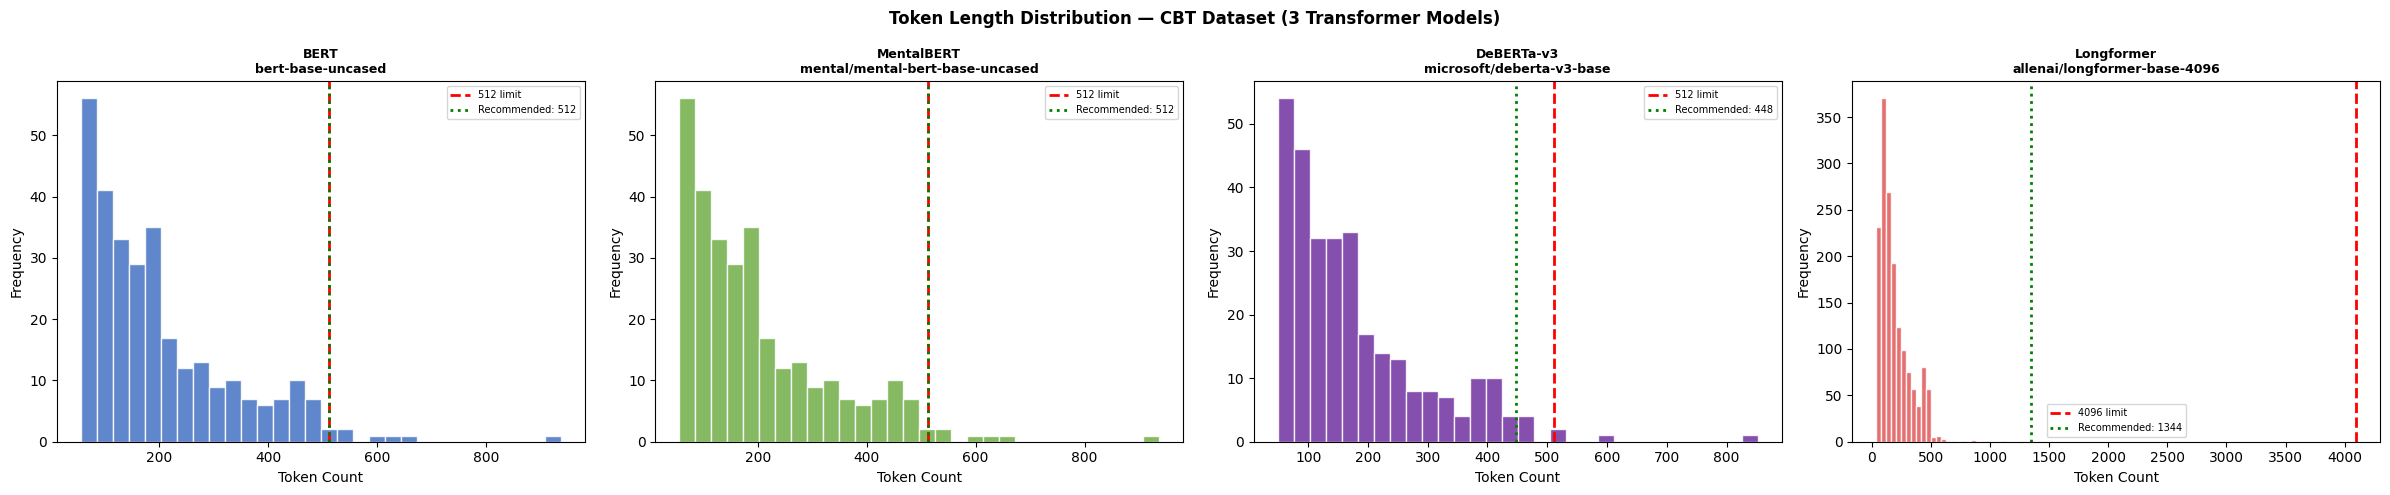

Token length visualization saved!


In [12]:
# Visualization - token length
fig, axes = plt.subplots(1, len(MODEL_REGISTRY), figsize=(6 * len(MODEL_REGISTRY), 5))
colors    = ['#4472C4', '#70AD47', '#7030A0', '#E15759']

for idx, (model, color) in enumerate(zip(MODEL_REGISTRY, colors)):
    ax   = axes[idx]
    name = model['name']
    if name not in token_stats:
        ax.text(0.5, 0.5, 'Failed to load', ha='center')
        continue
    lengths = token_stats[name]
    max_len = recommended_max_len[name]

    ax.hist(lengths, bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(model['max_tokens'], color='red',   linewidth=2, linestyle='--',
               label=f"{model['max_tokens']} limit")
    ax.axvline(max_len,             color='green', linewidth=2, linestyle=':',
               label=f'Recommended: {max_len}')
    ax.set_title(f'{name}\n{model["hf_id"]}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Token Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle('Token Length Distribution — CBT Dataset (3 Transformer Models)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}token_lengths_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Token length visualization saved!')


In [13]:
# Save Preprocessed Data
SAVE_COLS = [
    'Id_Number',
    'Patient Question',      # raw — used by ML baselines directly
    'text_for_bert',         # bert-base-uncased
    'text_for_mentalbert',   # mental/mental-bert-base-uncased
    'text_for_deberta',      # microsoft/deberta-v3-base
    'text_for_longformer',   # allenai/longformer-base-4096
    'label',                 # 0-10 -> CDT head
    'Dominant Distortion',   # class name
    'Distorted part',        # ground-truth rationale span (for XAI evaluation)
    'secondary_distortion',
]

train_final[SAVE_COLS].to_csv(f'{DATA_OUTPUT_DIR}cbt_train.csv', index=False)
val_df[SAVE_COLS].to_csv(f'{DATA_OUTPUT_DIR}cbt_val.csv',        index=False)
test_df[SAVE_COLS].to_csv(f'{DATA_OUTPUT_DIR}cbt_test.csv',      index=False)

# Metadata
metadata = {
    'dataset'  : 'CBT Cognitive Distortion Dataset (Shreevastava & Foltz)',
    'task'     : 'Cognitive Distortion Detection — CDT Head',
    'approach' : '3 Transformers + 2 ML Baselines',
    'splits'   : {
        'train': len(train_final),
        'val'  : len(val_df),
        'test' : len(test_df)
    },
    'models' : {
        m['name']: {
            'hf_id'    : m['hf_id'],
            'text_col' : m['text_col'],
            'max_len'  : recommended_max_len.get(m['name'], 512),
            'lowercase': m['lowercase'],
            'note'     : m['note'],
        }
        for m in MODEL_REGISTRY
    },
    'ml_baselines': {
        'LR' : {
            'name'    : 'TF-IDF + Logistic Regression',
            'text_col': 'Patient Question',
        },
        'SVM': {
            'name'    : 'TF-IDF + SVM',
            'text_col': 'Patient Question',
        }
    },
    'labels' : {
        'cdt_head': {str(k): v for k, v in ID2LABEL.items()},
    },
    'class_weights': {
        'cdt_head': [float(x) for x in weights_cdt.round(4)],
    },
    'num_labels': {
        'cdt_head': len(DISTORTION_LABELS),
    },
    'random_seed'  : RANDOM_SEED,
    'rationale_column': 'Distorted part',
    'secondary_distortion_note': (
        'Secondary Distortion is carried through as metadata only — not used '
        'as a modeling target. Only 416/2530 samples have one, and it reflects '
        'a subjective annotator judgement call, not a reliable supervised label.'
    ),
    'therapist_responses_note': (
        'Therapist_responses.csv was intentionally excluded from this pipeline. '
        'It contains patient-question -> therapist-answer dialogue pairs, not '
        'distortion labels, and does not fit this classification task.'
    ),
    'preprocessing': {
        'contractions'      : f'{len(CONTRACTIONS)} patterns',
        'negation_preserved': True,
        'repeated_chars'    : True,
        'punctuation_norm'  : True,
        'stopword_removal'  : False,
        'lemmatization'     : False,
        'ml_baseline_note'  : 'Raw Patient Question text used — TfidfVectorizer handles tokenization',
    }
}

with open(f'{DATA_OUTPUT_DIR}metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('All files saved!')
print(f'  cbt_train.csv :{len(train_final)} rows')
print(f'  cbt_val.csv   :{len(val_df)} rows')
print(f'  cbt_test.csv  :{len(test_df)} rows')


All files saved!
  cbt_train.csv :1618 rows
  cbt_val.csv   :405 rows
  cbt_test.csv  :506 rows


In [14]:
check_df = pd.read_csv(f'{DATA_OUTPUT_DIR}cbt_train.csv')
check_df.head()


,Id_Number,Patient Question,text_for_bert,text_for_mentalbert,text_for_deberta,text_for_longformer,label,Dominant Distortion,Distorted part,secondary_distortion
0,1669,"This is a problem I’ve had my whole life, but ...","this is a problem i ve had my whole life, but ...","this is a problem i ve had my whole life, but ...","this is problem ve had my whole life, but ve a...","This is a problem I ve had my whole life, but ...",7,Magnification,Whenever plans show signs of failing or it loo...,Personalization
1,2175,My sister-44 and mother-72 live together. Both...,my sister-44 and mother-72 live together. both...,my sister-44 and mother-72 live together. both...,my sister-44 and mother-72 live together. both...,My sister-44 and mother-72 live together. Both...,2,Overgeneralization,"Though they both see psychiatrists for meds, n...",NaN
2,4552,I’ve been sitting here for 30 minutes trying t...,i ve been sitting here for 30 minutes trying t...,i ve been sitting here for 30 minutes trying t...,ve been sitting here for 30 minutes trying to ...,I ve been sitting here for 30 minutes trying t...,9,Mind Reading,I feel nothing on a regular basis. For example...,Overgeneralization
3,1537,From Singapore: My GF (22 years old) and I ha...,from singapore my gf 22 years old and i had be...,from singapore my gf 22 years old and i had be...,from singapore my gf 22 years old and had been...,From Singapore My GF 22 years old and I had be...,0,No Distortion,NaN,NaN
4,430,My fiancé’ and I have been together for 4 and ...,my fianc and i have been together for 4 and 1 ...,my fianc and i have been together for 4 and 1 ...,my fianc and have been together for 4 and 1 2 ...,My fianc and I have been together for 4 and 1 ...,0,No Distortion,NaN,NaN


In [15]:
check_df.columns.tolist()


['Id_Number',
 'Patient Question',
 'text_for_bert',
 'text_for_mentalbert',
 'text_for_deberta',
 'text_for_longformer',
 'label',
 'Dominant Distortion',
 'Distorted part',
 'secondary_distortion']